CS225 Sequence-based Machine Learning for Bioinformatics

San Jose State University, Spring 2024

Worksheet #5

Deep Learning Intro with the MNIST dataset

This tutorial uses the Keras package, which has been a part of TensorFlow since 2017.

Code adopted from tutorial by Jan Balewski, NERSC.


## Classifier of  MNIST images - these are images of hand-written digits

## Worksheet objective: to give you a general idea of how deep learning classifies images into groups. The same principles apply to bioinformatics use cases.

## Data set: MNIST hand-written digits

## Exercise objective: train a deep learning model that can understand which digit a hand-written number represents (if any). It is challenging to correctly identify hand-written digits or letters, especially if the writer had a bad hand-writing.

## Part 1
### format input data , split, save as hd5



In [1]:

# IMPORTANT : reset all variables in this notebook
%reset -f

# load all python modules
from keras.datasets import mnist
#from keras import utils as np_utils
from keras.utils import to_categorical
from keras.models import Model, load_model
from keras.layers import Dense, Dropout, Input,Flatten,LSTM
import numpy as np
import time, os, h5py

import matplotlib.pyplot as plt
%matplotlib inline


### Format MNIST 28x28 data as pairs of split images, make good & bad pairs, save as HDF5

In [2]:
#sect 1.2
print('read raw MNIST data ...')
# Load pre-shuffled MNIST data into train and test sets, h 60k images
(Ximg, Ydig), (_,_) = mnist.load_data()
nb_labels = 10 # digits 0-9
# we will ignore Xt,Yt
print('raw MNIST  input Ximg:',Ximg.shape,' Ydig:',Ydig.shape)

read raw MNIST data ...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
raw MNIST  input Ximg: (60000, 28, 28)  Ydig: (60000,)


## Always check if the input makes sense

sampleX numerical values of image: [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0 172 253   0   0   0]
plot input raw for  image idx= [1, 2, 7, 12, 22, 67, 68]


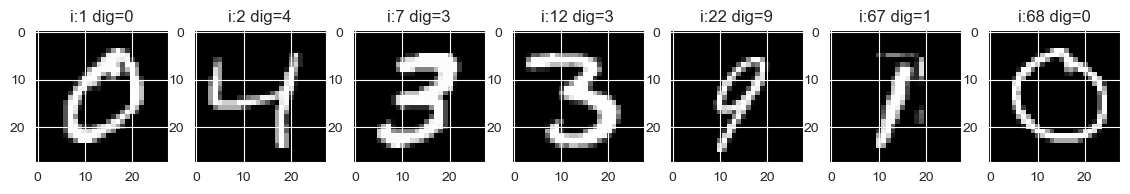

In [3]:
#Sect 1.3
# always check if the input makes sense
print('sampleX numerical values of image:',Ximg[0][:,5])
def plot_input_raw(X,Yd,idxL):
    nrow,ncol=1,len(idxL)
    print('plot input raw for  image idx=',idxL)
    yIn=2.
    fig=plt.figure(1,facecolor='white', figsize=(yIn*ncol,yIn))
    j=0
    for i in idxL:
        #  grid is (yN,xN) - y=0 is at the top,  so dumm
        ax = plt.subplot(nrow, ncol, 1+j)
        tit='i:%d dig=%d'%(i,Yd[i])
        ax.set(title=tit)
        ax.imshow(X[i], cmap=plt.get_cmap('gray'))
        j+=1
# check the data
plot_input_raw(Ximg,Ydig,[1,2,7,12,22,67,68])  # check the data

In [5]:
# sect 1.4
# convert labels 0-9 to 1-hot encodding
print('sampleY digit:',Ydig[0])
Yhot = to_categorical(Ydig, nb_labels).astype('float32')
print('sampleY 1-hot:',Yhot[0])

sampleY digit: 5
sampleY 1-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


**Question:**

1) In this instance, what does the one-hot encoded value (sampleY 1-hot) that is printed mean?

**Answer**
Label, true value. location of 1 indicates which digit it is.

In [7]:
#Sect 1.5
# split input data onto train/validation/test  subsets, default ratio: 7/2/1
# renormalize pixel values from 0-255 to 0.0-1.0
# shuffle data just in case
# output is in data{train/val/test}

def split_input(Ximg,Yhot,trainFrac=0.7, valFrac=0.2):
    mxeve=len(Ximg)
    data={}
    # establish 3 domains:
    for dom in ['train','val','test']:
        data[dom]={'X':[],'Y':[]}

    prob2=trainFrac+valFrac
    assert prob2 <1
    assert trainFrac <prob2

    for i in range(mxeve):
        x=Ximg[i].astype('float32')/255
        y=Yhot[i]
        #if i==0: print('sample2 numerical values of image:',x[:,5])
        r=np.random.uniform()
        if r <trainFrac :
            dom='train'
        elif r <prob2 :
            dom='val'
        else:
            dom='test'

        data[dom]['X'].append(x)
        data[dom]['Y'].append(y)

    #print('split pairs: ',end='')

    # convert data to np.array
    for dom in data:
        for x in data[dom]:
            data[dom][x]=np.array(data[dom][x])
        #print(dom, data[dom]['X'].shape, end=', ')
    print()

    return data

# unit test
data1=split_input(Ximg,Yhot)
print('data assigned to domains:',list(data1))
print('X-data :',data1['train']['X'].shape, ', Y-data :',data1['train']['Y'].shape)
print('X-data :',data1['val']['X'].shape, ', Y-data :',data1['val']['Y'].shape)
print('X-data :',data1['test']['X'].shape, ', Y-data :',data1['test']['Y'].shape)


data assigned to domains: ['train', 'val', 'test']
X-data : (42121, 28, 28) , Y-data : (42121, 10)
X-data : (11914, 28, 28) , Y-data : (11914, 10)
X-data : (5965, 28, 28) , Y-data : (5965, 10)


**Question:**

2) What is the difference between the training, validation vs. testing segments?
**Answer**
- Training data: Train the model
- Validation data: Check models during training, decide early stopping
- Testing data: After training, check how well the model performs with unseen data.

3) How many images are in the training, validation, testing segments?

Train: 42121

Validation: 11914

Test: 5965

## formating raw data is time consuming, we only needed to do it once. Save the split data as hd5 files to save  your time in the future


In [8]:
#sect 1.6
# formating raw data is time consuming, we only needed to do it once. Save the split data as hd5 files to save  your time in the future
def save_input_hdf5(data):
        outF='mnist_split.data.h5'
        print('saving data as hdf5:',outF)
        h5f = h5py.File(outF, 'w')
        for dom in data:
            for xy in data[dom]:
                xobj=data[dom][xy]
                lab=dom+'_'+xy
                print('h5-write ',lab,type(xobj),xobj.shape,xobj.dtype)
                h5f.create_dataset(lab, data=xobj)
        #for x in h5f.keys():
        #    print(x,self.data[x].shape)
        h5f.close()
        xx=os.path.getsize(outF)/1048576
        print('closed  hdf5:',outF,' size=%.2f MB'%xx)

# unit test
save_input_hdf5(data1)

saving data as hdf5: mnist_split.data.h5
h5-write  train_X <class 'numpy.ndarray'> (42121, 28, 28) float32
h5-write  train_Y <class 'numpy.ndarray'> (42121, 10) float32
h5-write  val_X <class 'numpy.ndarray'> (11914, 28, 28) float32
h5-write  val_Y <class 'numpy.ndarray'> (11914, 10) float32
h5-write  test_X <class 'numpy.ndarray'> (5965, 28, 28) float32
h5-write  test_Y <class 'numpy.ndarray'> (5965, 10) float32
closed  hdf5: mnist_split.data.h5  size=181.74 MB


## Part 2
###  read hd5 data, define  model, train  model, save it

In [ ]:
# Sect 2.1
def load_input_hdf5(dataL):
        inpF5='mnist_split.data.h5'
        start = time.time()
        print('load new data from hdf5:',inpF5)
        data={ dom:{} for dom in dataL}
        h5f = h5py.File(inpF5, 'r')
        for lab in h5f.keys():
            for y in dataL:
                if y not in lab: continue
                print('load:',lab)
                dom,xy=lab.split('_')
                data[dom][xy] = h5f[lab][:]
                print(' done',data[dom][xy].shape)
        h5f.close()
        print('load_input_hdf5 done, elaT=%.1f sec'%(time.time() - start))
        return data
# unit test
data2=load_input_hdf5(['train','val'])

load new data from hdf5: mnist_split.data.h5
load: train_X
 done (29929, 28, 28)
load: train_Y
 done (29929, 10)
load: val_X
 done (14880, 28, 28)
load: val_Y
 done (14880, 10)
load_input_hdf5 done, elaT=0.0 sec


In [ ]:
data2['train']['X'].shape

(29929, 28, 28)

In [ ]:
data2['train']['Y'].shape

(29929, 10)

In [ ]:
#Sect 2.2

def build_model(data,dropFrac=0.10):
        # based  https://keras.io/getting-started/functional-api-guide/
        start = time.time()
        sh1=data['train']['X'].shape
        nDig=data['train']['Y'].shape[1]
        input1 = Input(shape=(sh1[1],sh1[2]), name='image')
        print('build_model input1 shape:',input1.shape,' nDig=',nDig)

        # set dimension of hidden layers
        dens1=30; dens2=20; lstm1=20

        # assemble model using API
        # use only fully connected layers (Dens)
        net=Flatten(name='to_1d')(input1)
        net=Dropout(dropFrac)(net)

        net=Dense(dens1, activation='relu',name='fc1')(net)
        net=Dropout(dropFrac)(net)
        net=Dense(dens2, activation='relu',name='fc2')(net)
        net=Dropout(dropFrac)(net)
        outputs=Dense(nDig, activation='softmax',name='digit')(net)
        model = Model(inputs=input1, outputs=outputs)

        # Compile model
        model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
        model.summary() # will print
        print('model size=%.1fK compiled elaT=%.1f sec'%(model.count_params()/1000.,time.time() - start))
        return model

# build the model
model2=build_model(data2)

build_model input1 shape: (None, 28, 28)  nDig= 10
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 28, 28)]          0         
                                                                 
 to_1d (Flatten)             (None, 784)               0         
                                                                 
 dropout_6 (Dropout)         (None, 784)               0         
                                                                 
 fc1 (Dense)                 (None, 30)                23550     
                                                                 
 dropout_7 (Dropout)         (None, 30)                0         
                                                                 
 fc2 (Dense)                 (None, 20)                620       
                                                                 
 dropout

**Question:**
Read the description of the model that gets printed out.

4) What is the dimensionality of an instance that this network takes as input?
Hint: see "build_model input1 shape: ...."

28*28 = 784


5) What is a "dense" layer? What is the purpose of the "dropout" layer between dense layers? What does dropout do to the outputs of neurons from previous dense layer?

A dense layer means each nuron is connected to all neurons from previous layer.
Drop out is randomly removing some outputs to prevent overfitting.


6) What does the 'adam' optimizer that is defined as a parameter do?

Adam is a fast and effective optimizer that combines AdaGrad and Momentum.

7) How many output numbers does the final output layer that has type activation='softmax' produce? You can google 'softmax' to find out.

10 numbers representing the probabilities of prediction for each digit 0-9.


###  train model, save weights

In [ ]:
# Sect 2.3
def train_model(model,data,batch_size=100,epochs=5):
        X=data['train']['X']
        Y=data['train']['Y']
        X_val=data['val']['X']
        Y_val=data['val']['Y']
        print('\nTrain_model X:',X.shape,'  Y:',Y.shape,' epochs=',epochs,' batch size=',batch_size)
        start = time.time()
        hir=model.fit(X,Y,
                 validation_data=(X_val,Y_val),  shuffle=True,
                 batch_size=batch_size, epochs=epochs,
                 verbose=1)
        train_hirD=hir.history


        #evaluate performance for the last epoch
        acc=train_hirD['val_accuracy'][-1]
        loss=train_hirD['val_loss'][-1]
        fitTime=time.time() - start
        print('\n End Validation Accuracy:%.3f'%acc, ', Loss:%.3f'%loss,', fit time=%.1f sec'%(fitTime))
        return train_hirD

# unit test : LSTM-version: 13 sec/epoch,  FC-version: 1sec/epoch
train_history2=train_model(model2,data2,epochs=12)


Train_model X: (29929, 28, 28)   Y: (29929, 10)  epochs= 12  batch size= 100
Epoch 1/12
300/300 [==============================] - 2s 5ms/step - loss: 0.6690 - accuracy: 0.8092 - val_loss: 0.3215 - val_accuracy: 0.9087
Epoch 2/12
300/300 [==============================] - 1s 4ms/step - loss: 0.2754 - accuracy: 0.9202 - val_loss: 0.2518 - val_accuracy: 0.9265
Epoch 3/12
300/300 [==============================] - 1s 4ms/step - loss: 0.2275 - accuracy: 0.9344 - val_loss: 0.2216 - val_accuracy: 0.9339
Epoch 4/12
300/300 [==============================] - 1s 4ms/step - loss: 0.1961 - accuracy: 0.9435 - val_loss: 0.2052 - val_accuracy: 0.9407
Epoch 5/12
300/300 [==============================] - 1s 4ms/step - loss: 0.1733 - accuracy: 0.9497 - val_loss: 0.1902 - val_accuracy: 0.9432
Epoch 6/12
300/300 [==============================] - 1s 4ms/step - loss: 0.1565 - accuracy: 0.9550 - val_loss: 0.1844 - val_accuracy: 0.9469
Epoch 7/12
300/300 [==============================] - 1s 4ms/step - lo

**Question:**

8) Do you expect loss and val_loss to go up or down through the epochs?

Loss should go down. However, train loss may go down constantly unless it stucks in a local minima, validation loss may go up at some point, which indicates overfitting.

9) How about accuracy and val_accuracy?
Accuracy overall goes up, But while training accuracy may go up constantly, validation accuracy may go down at some point, which indicates overfitting.


10) What is the difference between accuracy and val_accuracy?
Accuracy is how well the model performs on training data. Val_accuracy is how well the model performs on validation data.

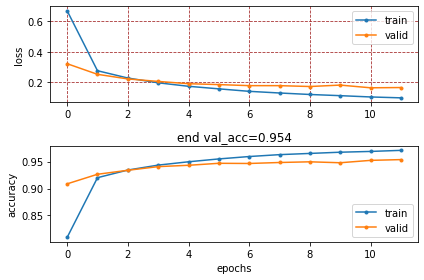

In [ ]:
#Sect 2.4
def plot_train_hir(train_hirD):
        ax1 = plt.subplot(2,1,1)
        ax2 = plt.subplot(2,1,2)

        DL=train_hirD
        val_acc=DL['val_accuracy'][-1]

        tit1=''
        tit2='end val_acc=%.3f'%(val_acc)

        ax1.set(ylabel='loss',title=tit1)
        ax1.plot(DL['loss'],'.-',label='train')
        ax1.plot(DL['val_loss'],'.-',label='valid')
        ax1.legend(loc='best')
        ax1.grid(color='brown', linestyle='--',which='both')

        ax2.set(xlabel='epochs',ylabel='accuracy',title=tit2)
        ax2.plot(DL['accuracy'],'.-',label='train')
        ax2.plot(DL['val_accuracy'],'.-',label='valid')
        ax2.legend(loc='lower right')

        plt.tight_layout()
plot_train_hir(train_history2)

In [ ]:
# sect 2.5
def save_modelA(model):
        outF='mnist_full.model.h5'
        print('save model full to',outF)
        model.save(outF)
        xx=os.path.getsize(outF)/1048576
        print('closed  hdf5:',outF,' size=%.2f MB'%xx)
# unit test
save_modelA(model2)

def load_modelA():
        fname='mnist_full.model.h5'
        print('load model from ',fname)
        model=load_model(fname) # creates model from HDF5
        model.summary() #will print
        return model

save model full to mnist_full.model.h5
closed  hdf5: mnist_full.model.h5  size=0.32 MB


## Part 3
### make predictions

In [ ]:
#Sect 3.1
# load 'test' data, never seen by the model
dom='test'
data3=load_input_hdf5([dom])
Xt=data3[dom]['X']
Yt=data3[dom]['Y']

print('\n see data Xt',Xt.shape,'  Yt',Yt.shape)


# load model
model3=load_modelA()

load new data from hdf5: mnist_split.data.h5
load: test_X
 done (15191, 28, 28)
load: test_Y
 done (15191, 10)
load_input_hdf5 done, elaT=0.0 sec

 see data Xt (15191, 28, 28)   Yt (15191, 10)
load model from  mnist_full.model.h5
Model: "model_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 image (InputLayer)          [(None, 28, 28)]          0         
                                                                 
 to_1d (Flatten)             (None, 784)               0         
                                                                 
 dropout_6 (Dropout)         (None, 784)               0         
                                                                 
 fc1 (Dense)                 (None, 30)                23550     
                                                                 
 dropout_7 (Dropout)         (None, 30)                0         
                           

In [ ]:
# Sect 3.2
# make predictions
start = time.time()
out=model3.predict(Xt)
predTime=time.time() - start
print('prediction done ',out.shape,' elaT=%.1 sec',predTime)

prediction done  (15191, 10)  elaT=%.1 sec 0.7788565158843994


In [ ]:
# note, predictions are 10 'probabilities'  that the image X_i is digit 0-9, lets print one
i=4
print('pred for i=',i,' probs:',out[i])

pred for i= 4  probs: [1.1660108e-05 1.3291425e-04 7.1424222e-09 1.8724316e-03 1.5938209e-03
 8.0847203e-06 3.4969131e-07 7.6520257e-03 5.8813410e-05 9.8866987e-01]


plot input raw for  image idx= [4]


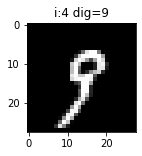

In [ ]:
plot_input_raw(Xt,np.argmax(Yt,axis=-1),[i])

**Question:**

11) From looking at the probabilities printed above (these were output from the softmax activation layer), which digit is this testing instance most likely to be?

9, out[i][9] has the largest value.


In [ ]:
# Sect 3.3
# convert 10 probs to most probable digit
def hot2dig(yhot):
    return np.argmax(yhot,axis=-1)  #  make it vectoriezed

#unit test
dig=hot2dig(out[i])
print('i=',i,'dig=',dig)

i= 90 dig= 2


In [ ]:
# lets convert all predictions to digit
Ypred=hot2dig(out)
Ytrue=hot2dig(Yt)  # do the same for the truth, wil be easier to compare
print('prediction as dig',Ypred.shape,'; truth',Ytrue.shape)

prediction as dig (15191,) ; truth (15191,)


plot input raw for  image idx= [4, 2, 6, 23, 45, 56, 87]
True      digits  [array([9, 5, 1, 6, 4, 6, 3])]
Predicted digits  [array([9, 5, 3, 6, 4, 6, 3])]


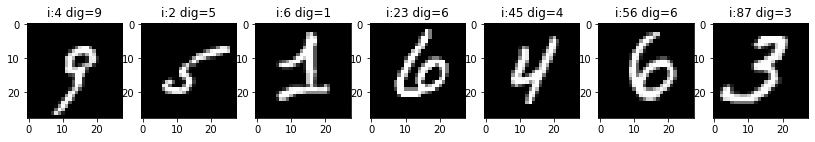

In [ ]:
#Sect 3.4
# Display a few images and print the predictions
iL=[4,2,6,23,45,56,87] # random list of images
plot_input_raw(Xt,Ytrue,iL)
print('True      digits ',[Ytrue[iL]])
print('Predicted digits ',[Ypred[iL]])

In [ ]:
# Sect 3.5
#  count how often predictions are correct/wrong
nAll=Ytrue.shape[0]
nGood= (Ytrue==Ypred).sum()
print('all=',nAll,' good=',nGood)
nBad=nAll -nGood
acc=nGood/nAll
print('acc=%.3f, nBad=%d'%(acc,nBad))

all= 15191  good= 14454
acc=0.951, nBad=737


In [ ]:
# lets display a few bad (wrong) predictions
jL=Ytrue==Ypred
iL=np.argsort(jL) #sort such that wrong predictions are first
iL=iL[:5]
print('index of first 5 bad predictions',iL)
print('True      digits ',[Ytrue[iL]])
print('Predicted digits ',[Ypred[iL]])

index of first 5 bad predictions [ 3162 13495  3484  6148 13499]
True      digits  [array([2, 9, 3, 3, 5])]
Predicted digits  [array([8, 4, 4, 8, 3])]


plot input raw for  image idx= [ 3162 13495  3484  6148 13499]


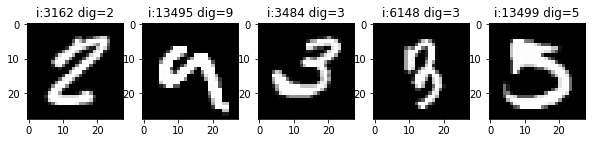

In [ ]:
#plot the bad (wrong) image predictions
plot_input_raw(Xt,Ytrue,iL)


Question:

12) In your opinion, why could some of these hand-written digits have been misclassified?

Maybe the training data was not representative enough. or Maybe the model stucture is not the best for this task.